In [ ]:
!pip install numba
!pip uninstall -y numpy
!pip install numpy==2.0.0

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 73.3 MB/s eta 0:00:00


In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import seaborn as sns
import numpy as np
from numba import njit
from numba.typed import List

def make_pretty():
    sns.set_theme(palette="plasma")
    plt.rcParams['figure.facecolor'] = 'black'
    plt.rcParams['axes.facecolor'] = 'black'
    plt.rcParams['axes.edgecolor'] = 'white'
    plt.rcParams['axes.labelcolor'] = 'white'
    plt.rcParams['xtick.color'] = 'white'
    plt.rcParams['ytick.color'] = 'white'
    plt.rcParams['text.color'] = 'white'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'black'
    plt.rcParams['savefig.edgecolor'] = 'black'

def colorline(X, Y, t, cmap="plasma"):
    points = np.array([X, Y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    normed_t = Normalize(vmin=t.min(), vmax=t.max())
    line_collection = LineCollection(segments, array=t, norm=normed_t, cmap=cmap)

    return line_collection

make_pretty()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fractal = np.load("cooler_fractal.npy")
plt.imsave("cooler_fractal.png", fractal, cmap='twilight')

Using: cuda
[0 0 0 ... 2 2 2]


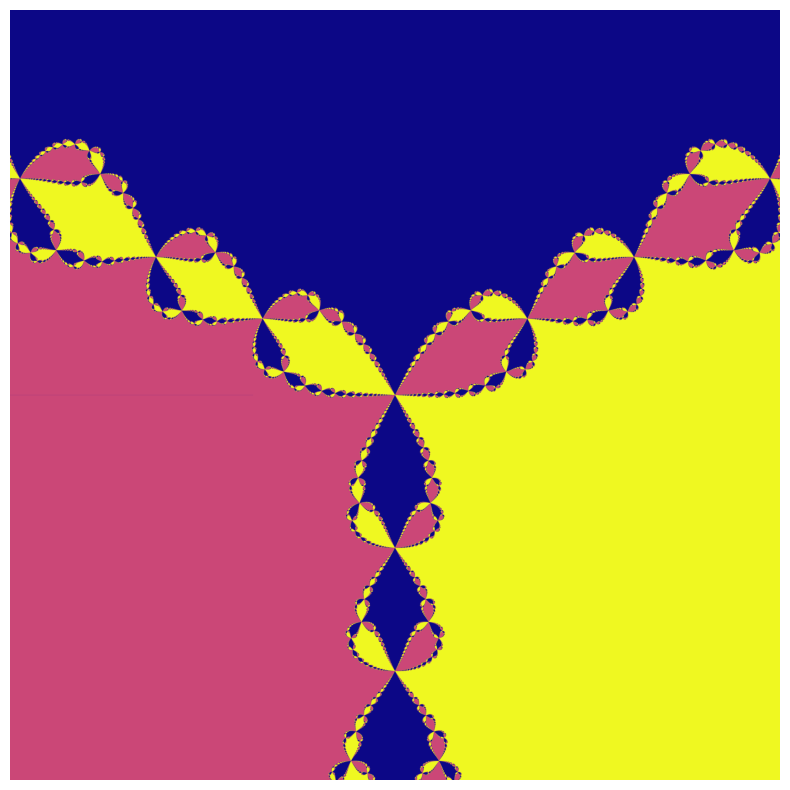

In [5]:
import torch
from numba import njit, prange
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

#some examples
# def f(z):
#     return z**3 + 1

# def df(z):
#     return 3 * z**2

# def f(z):
#     return z**2 + 1

# def df(z):
#     return 2 * z

# def f(z):
#     return (z**5 + z**3 + 1) / (z**4 + z**2 + 1)

# def df(z):
#     numerator = (5 * z**4 + 3 * z**2) * (z**4 + z**2 + 1) - (z**5 + z**3 + 1) * (4 * z**3 + 2 * z)
#     denominator = (z**4 + z**2 + 1)**2
#     return numerator / denominator

# def f(z):
#     return (z**6 - z**3 + 2) / (z**5 + z**2 - 1)

# def df(z):
#     numerator = (6 * z**5 - 3 * z**2) * (z**5 + z**2 - 1) - (z**6 - z**3 + 2) * (5 * z**4 + 2 * z)
#     denominator = (z**5 + z**2 - 1)**2
#     return numerator / denominator


# Newton iteration of whole gird of ic
def newton(z, f, df, max_iter, tol, h=1):
    #stores if a given point has converged or not, init all to no, torch tensor
    converged = torch.zeros_like(z, dtype=torch.bool)
    #stores the root of a given initial guess, init with nan to clearly mark roots that dont converge
    #so they can be marked spacifically later
    roots = torch.full_like(z, complex('nan'))
    #looping through entire grid at once, need to be careful of doing extra work
    for i in range(max_iter):
        #step size
        dz = f(z) / df(z)
        #compute change
        z_next = z - h * dz
        #check convergence
        pt_converge = torch.abs(dz) < tol
        # ~ element wise not
        # updates roots if algorithm converged for a given root
        # ie pt_converge and not already marked as converged -> mark as converged to freeze that value of z
        roots[pt_converge & ~converged] = z[pt_converge & ~converged]
        #element wise or -> converged updated to mark any newly converged points
        converged |= pt_converge
        #update z
        z = z_next
    return roots

#numba will throw a fit if you dare to pass a tensor to it so need to convert to
#numpy array and specify to use cpu
#return vector of length n^2
def numba_friendly_roots(roots):
    return roots.flatten().cpu().numpy()

#switching to numba for cpu heavy task like this dumb iteration, must specifiy to
#torch that we are switching to numpy array
@njit(parallel=True)
def sort_roots(roots_NP, tol=1e-3):
    n = roots_NP.size
    #stores which root is converged to based on index of that root in unique root array, will leave diverged ic roots as -1
    indices = np.full(n, -1, dtype=np.int32)

    #Numba will also yell at you if you try to resize a list mid loop, set to n
    #since could never be more roots than this
    unique_roots = np.empty(n, dtype=roots_NP.dtype)

    #keep track of number of roots found to get rid of most of unique_roots later
    unique_count = 0

    #loop through all the found roots
    for i in prange(n):
        r = roots_NP[i]
        #since we let diverging roots stay nan need to ignore them, must check real and imaginary part seperately
        #for numba reasons otherwise you die
        if np.isnan(r.real) or np.isnan(r.imag):
            continue
        #init to not found yet
        found = False
        #check against all other roots found so far
        for j in range(unique_count):
            if abs(r - unique_roots[j]) < tol:
                indices[i] = j
                found = True
                break
        #add to unique if not found yet
        if not found:
            unique_roots[unique_count] = r
            #its index is the unique count since new
            indices[i] = unique_count
            unique_count += 1
    unique_roots = unique_roots[:unique_count]
    return unique_roots, indices


def fractal(f, df, max_iter=50, tol=1e-3, res=128, fov_size=10):
    # make complex plane
    xmin, ymin = -fov_size, -fov_size
    xmax, ymax = fov_size, fov_size
    x = torch.linspace(xmin, xmax, res, device=device)
    y = torch.linspace(ymin, ymax, res, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    Z = X + 1j * Y

    z0 = Z.clone()

    roots = newton(z0, f, df, max_iter, tol)
    unique_roots, root_indices = sort_roots(numba_friendly_roots(roots))
    print(root_indices)
    return root_indices.reshape(res, res)

frac = fractal(f, df, max_iter=100, tol=1e-6, res=10000, fov_size=2)

plt.figure(figsize=(10, 10))
#fix the fucking colors
plt.imshow((frac), cmap='plasma')
plt.axis('off')
plt.savefig("cubic_frac", dpi=1000, bbox_inches='tight', pad_inches=0)
plt.show()